In [27]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from collections import deque

%matplotlib inline

np.random.seed(42)

env = gym.make("Taxi-v3", render_mode="ansi")

print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

Number of states: 500
Number of actions: 6


In [28]:
def reset_env(env):
    """Reset env and return only observation (state id)."""
    obs, info = env.reset()
    return obs

def step_env(env, action):
    """
    Step env, unify terminated/truncated → done.
    """
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    return obs, reward, done, info

def render_env(env):
    """Print ASCII Taxi grid."""
    print(env.render())


In [29]:
def build_neighbors(env):
    """
    Build a dict mapping (row, col) :- list of (next_row, next_col, action)
    using the true Taxi transition model.
    We ignore passenger and destination, and just look at taxi movement.
    """
    neighbors = {}
    for row in range(5):
        for col in range(5):
            neigh = []
            for action in [0, 1, 2, 3]:  # South, North, East, West
                # encode a dummy state: passenger in taxi (4), dest = 0
                state = env.unwrapped.encode(row, col, 4, 0)
                transitions = env.unwrapped.P[state][action]
                prob, next_state, reward, done = transitions[0]
                nr, nc, _, _ = env.unwrapped.decode(next_state)

                # if move doesn't change row/col, there's a wall → ignore
                if (nr, nc) != (row, col):
                    neigh.append((nr, nc, action))
            neighbors[(row, col)] = neigh
    return neighbors

neighbors = build_neighbors(env)
neighbors


{(0, 0): [(1, 0, 0), (0, 1, 2)],
 (0, 1): [(1, 1, 0), (0, 0, 3)],
 (0, 2): [(1, 2, 0), (0, 3, 2)],
 (0, 3): [(1, 3, 0), (0, 4, 2), (0, 2, 3)],
 (0, 4): [(1, 4, 0), (0, 3, 3)],
 (1, 0): [(2, 0, 0), (0, 0, 1), (1, 1, 2)],
 (1, 1): [(2, 1, 0), (0, 1, 1), (1, 0, 3)],
 (1, 2): [(2, 2, 0), (0, 2, 1), (1, 3, 2)],
 (1, 3): [(2, 3, 0), (0, 3, 1), (1, 4, 2), (1, 2, 3)],
 (1, 4): [(2, 4, 0), (0, 4, 1), (1, 3, 3)],
 (2, 0): [(3, 0, 0), (1, 0, 1), (2, 1, 2)],
 (2, 1): [(3, 1, 0), (1, 1, 1), (2, 2, 2), (2, 0, 3)],
 (2, 2): [(3, 2, 0), (1, 2, 1), (2, 3, 2), (2, 1, 3)],
 (2, 3): [(3, 3, 0), (1, 3, 1), (2, 4, 2), (2, 2, 3)],
 (2, 4): [(3, 4, 0), (1, 4, 1), (2, 3, 3)],
 (3, 0): [(4, 0, 0), (2, 0, 1)],
 (3, 1): [(4, 1, 0), (2, 1, 1), (3, 2, 2)],
 (3, 2): [(4, 2, 0), (2, 2, 1), (3, 1, 3)],
 (3, 3): [(4, 3, 0), (2, 3, 1), (3, 4, 2)],
 (3, 4): [(4, 4, 0), (2, 4, 1), (3, 3, 3)],
 (4, 0): [(3, 0, 1)],
 (4, 1): [(3, 1, 1), (4, 2, 2)],
 (4, 2): [(3, 2, 1), (4, 1, 3)],
 (4, 3): [(3, 3, 1), (4, 4, 2)],
 (4, 4): [

In [30]:
def shortest_path_actions(start, goal, neighbors):
    """
    Return a list of actions (0–3) giving the shortest path
    from start (row, col) to goal (row, col) using unweighted BFS.
    """
    if start == goal:
        return []

    queue = deque([start])
    prev = {start: None}
    prev_action = {start: None}

    while queue:
        cur = queue.popleft()
        if cur == goal:
            break

        for nr, nc, action in neighbors[cur]:
            nxt = (nr, nc)
            if nxt not in prev:
                prev[nxt] = cur
                prev_action[nxt] = action
                queue.append(nxt)

    if goal not in prev:
        return None

    actions = []
    cur = goal
    while prev[cur] is not None:
        actions.append(prev_action[cur])
        cur = prev[cur]
    actions.reverse()
    return actions


In [31]:
def run_dijkstra_episode(env, neighbors, max_steps=200):
    """
    Run one episode where the taxi follows shortest paths
    (grid Dijkstra) to passenger and then to destination.
    Returns total_reward, steps.
    """
    state = reset_env(env)
    total_reward = 0
    steps = 0
    done = False

    locs = env.unwrapped.locs  # list of coordinates for R, G, Y, B

    while not done and steps < max_steps:
        row, col, pass_idx, dest_idx = env.unwrapped.decode(state)

        # Decide current high-level goal
        if pass_idx < 4:
            # passenger is waiting at a landmark
            target_pos = tuple(locs[pass_idx])
            actions = shortest_path_actions((row, col), target_pos, neighbors)
            if actions is None:
                actions = []
            actions.append(4)  # Pickup
        else:
            # passenger is already in taxi, go to destination
            target_pos = tuple(locs[dest_idx])
            actions = shortest_path_actions((row, col), target_pos, neighbors)
            if actions is None:
                actions = []
            actions.append(5)  # Dropoff

        # Execute planned actions (we re-plan next loop if not finished)
        for a in actions:
            state, reward, done, info = step_env(env, a)
            total_reward += reward
            steps += 1
            if done or steps >= max_steps:
                break

    return total_reward, steps


Dijkstra planner baseline over 200 episodes
  Avg reward: 7.795
  Avg steps : 13.205
  Max reward: 15
  Min reward: 3


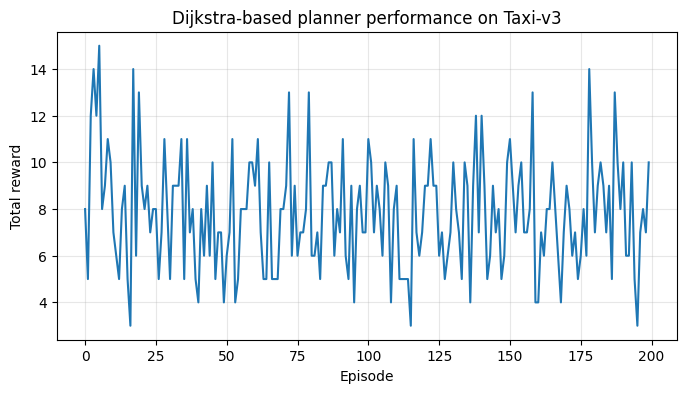

In [32]:
def evaluate_dijkstra_agent(env, neighbors, episodes=5000, max_steps=200):
    rewards = []
    steps_list = []

    for ep in range(episodes):
        total_reward, steps = run_dijkstra_episode(env, neighbors, max_steps)
        rewards.append(total_reward)
        steps_list.append(steps)

    return rewards, steps_list

d_rewards, d_steps = evaluate_dijkstra_agent(env, neighbors, episodes=200)

print("Dijkstra planner baseline over 200 episodes")
print("  Avg reward:", np.mean(d_rewards))
print("  Avg steps :", np.mean(d_steps))
print("  Max reward:", np.max(d_rewards))
print("  Min reward:", np.min(d_rewards))

plt.figure(figsize=(8,4))
plt.plot(d_rewards)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("Dijkstra-based planner performance on Taxi-v3")
plt.grid(True, alpha=0.3)
plt.show()
